In [1]:
from licenceplate_deaug_pytorch import Unet, GaussianDiffusion, Trainer
import torchvision
import argparse
import numpy as np
from matplotlib import pyplot as plt

#--time_steps 100 --aug_routine 'Default' --save_folder './generate_aug_mix_train'

class settings_args():
    def __init__(self):
        self.time_steps=100
        self.aug_routine='Default'
        self.save_folder='./qsample_test'
        self.train_steps = 700000
        self.load_path = None
        self.data_path_1='/data/licence_plate/_plate/generated_data/result2/img/'
        self.data_path_2='/data/licence_plate/_plate/generated_data/result3/img/'
        self.train_routine='Final'
        self.sampling_routine='x0_step_down'
        self.remove_time_embed=False
        self.residual=False
        self.loss_type='l1'
args=settings_args()

model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels=3,
    with_time_emb=not(args.remove_time_embed),
    residual=args.residual
).cuda()

diffusion = GaussianDiffusion(
    model,
    image_size = 256,
    device_of_kernel = 'cuda',
    channels = 3,
    timesteps = args.time_steps,        # number of steps
    loss_type = args.loss_type,                   # L1 or L2
    aug_routine=args.aug_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).cuda()

import torch
#diffusion = torch.nn.DataParallel(diffusion, device_ids=range(torch.cuda.device_count()))

trainer = Trainer(
    diffusion,
    [args.data_path_1,args.data_path_2],
    image_size = 256,
    train_batch_size = 1,
    train_lr = 2e-5,
    train_num_steps = args.train_steps, # total training steps
    gradient_accumulate_every = 2,      # gradient accumulation steps
    ema_decay = 0.995,                  # exponential moving average decay
    fp16 = False,                       # turn on mixed precision training with apex
    results_folder = args.save_folder,
    load_path = args.load_path,
    dataset = 'AOLP'
)

#trainer.train()


Is Time embed used ?  True
AOLP DA used


In [2]:




og_img = next(trainer.dl).cuda()


b, c, h, w, device, img_size, = *og_img.shape, og_img.device, trainer.model.image_size
assert h == img_size and w == img_size, f'height and width of image must be {img_size}'
t = torch.randint(0, trainer.model.num_timesteps, (b,), device=device).long()
trainer.model.aug_licence.random_parameter()
x_blur = trainer.model.q_sample(x_start=og_img, t=t)

print(t)

#test t to qsample
#for idx in range(trainer.model.num_timesteps):
#    print('t = %d'%(t))
#    t= torch.tensor([idx],device=device).long()
#    x_blur = trainer.model.q_sample(x_start=og_img, t=t)

print(x_blur.shape)

tensor([95], device='cuda:0')
torch.Size([1, 3, 256, 256])


x0 range between 0.392157 and 1.000000
xt range between 0.356863 and 0.992157
t = 95


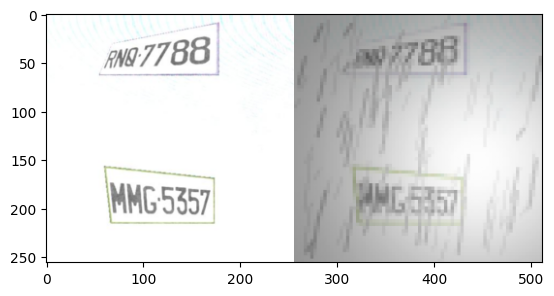

In [3]:
img_x0 = trainer.model.aug_licence.torchcuda2npy(og_img[0])
print('x0 range between %05f and %05f'%(np.min(img_x0),np.max(img_x0)))

img_xt = trainer.model.aug_licence.torchcuda2npy(x_blur[0])
print('xt range between %05f and %05f'%(np.min(img_xt),np.max(img_xt)))
print('t = %d'%(t))

plt.imshow(np.concatenate((img_x0,img_xt),axis=1))

In [4]:
samplext, _, all_images = trainer.ema_model.sample(batch_size=1, img=og_img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])
img_samplext range between 0.329412 and 0.992157
img_all_images range between 0.282353 and 1.062745


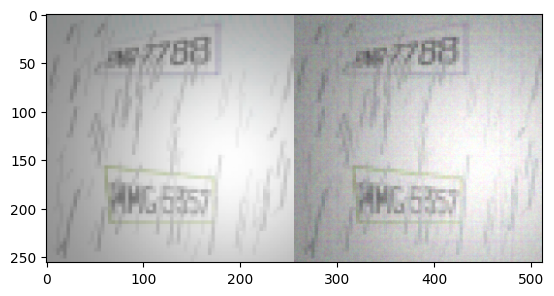

In [9]:
print(samplext.shape)
print(all_images.shape)
img_samplext = trainer.model.aug_licence.torchcuda2npy(samplext[0])
img_all_images = trainer.model.aug_licence.torchcuda2npy(all_images[0])
print('img_samplext range between %05f and %05f'%(np.min(img_samplext),np.max(img_samplext)))
print('img_all_images range between %05f and %05f'%(np.min(img_all_images),np.max(img_all_images)))
plt.imshow(np.concatenate((img_samplext,img_all_images),axis=1))

In [17]:
sample_img = og_img
sample_t = trainer.model.num_timesteps

with torch.no_grad():
    sample_img = trainer.model.func[sample_t-1](sample_img)

# 3(2), 2(1), 1(0)
sample_xt = sample_img

while(sample_t):
    step = torch.full((1,), sample_t - 1, dtype=torch.long).cuda()
    x = og_img #original code need reverse xt to x0' this test just use GT


    x_times = x
    with torch.no_grad():
        x_times = trainer.model.func[sample_t-1](x_times)

    x_times_sub_1 = x
    with torch.no_grad():
        x_times_sub_1 = trainer.model.func[sample_t-2](x_times_sub_1)

    x = sample_img - x_times + x_times_sub_1

    sample_img = x
    sample_t = sample_t - 1
    print(sample_t)
    


99
98
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0


sample_img_np range between 0.329412 and 0.992157
x_times_np range between 0.392157 and 1.000000
x_times_sub_1_np range between 0.329412 and 0.992157
x_np range between 0.329412 and 0.992157


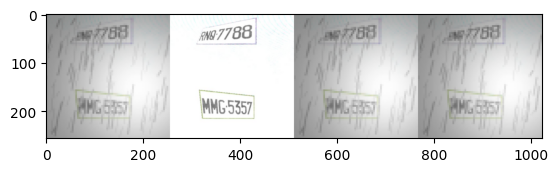

In [18]:
sample_img_np = trainer.model.aug_licence.torchcuda2npy(sample_img[0])
x_times_np = trainer.model.aug_licence.torchcuda2npy(x_times[0])
x_times_sub_1_np = trainer.model.aug_licence.torchcuda2npy(x_times_sub_1[0])
x_np = trainer.model.aug_licence.torchcuda2npy(x[0])

print('sample_img_np range between %05f and %05f'%(np.min(sample_img_np),np.max(sample_img_np)))
print('x_times_np range between %05f and %05f'%(np.min(x_times_np),np.max(x_times_np)))
print('x_times_sub_1_np range between %05f and %05f'%(np.min(x_times_sub_1_np),np.max(x_times_sub_1_np)))
print('x_np range between %05f and %05f'%(np.min(x_np),np.max(x_np)))
plt.imshow(np.concatenate((sample_img_np,x_times_np,x_times_sub_1_np,x_np),axis=1))